
**To Fetch Live Bioactivity Data from ChEMBL and Build a Supervised Regression Model (using Random Forest algorithm) for Predicting EGFR Inhibitor Potency (pIC50)**

In [ ]:
!pip install chembl_webresource_client rdkit pandas scikit-learn openpyxl -q

import pandas as pd
import numpy as np
from chembl_webresource_client.new_client import new_client

**Meaning:** This installs four things — chembl_webresource_client (ChEMBL's official API to fetch data), rdkit (converts chemical SMILES strings into numerical features later), pandas/numpy (data handling), and openpyxl (needed so pandas can read/write Excel .xlsx files, since we'll be producing an Excel file for GitHub, not just CSV). The -q just keeps the install output quiet. Nothing happens with data yet — this only loads the tools into memory.

In [ ]:
target = new_client.target
target_query = target.search('EGFR')
targets_df = pd.DataFrame.from_dict(target_query)
targets_df[['target_chembl_id', 'pref_name', 'organism']]

,target_chembl_id,pref_name,organism
0,CHEMBL4523747,EGFR/PPP1CA,Homo sapiens
1,CHEMBL5465557,CCN2-EGFR,Homo sapiens
2,CHEMBL3608,Epidermal growth factor receptor,Mus musculus
3,CHEMBL6193842,Protein cereblon/Epidermal growth factor receptor,Mus musculus
4,CHEMBL203,Epidermal growth factor receptor,Homo sapiens
5,CHEMBL4523680,Protein cereblon/Epidermal growth factor receptor,Homo sapiens
6,CHEMBL2363049,Epidermal growth factor receptor,Homo sapiens
7,CHEMBL3137284,MER intracellular domain/EGFR extracellular do...,Homo sapiens
8,CHEMBL4523998,von Hippel-Lindau disease tumor suppressor/Epi...,Homo sapiens
9,CHEMBL6193841,Protein cereblon/Epidermal growth factor receptor,Mus musculus


**Meaning of Block 2:**

Think of ChEMBL as a giant library, and every protein studied for drug research has its own "shelf" with a unique ID number. Since many proteins have similar names, we can't just say "give me EGFR data" — we first have to search and confirm we've got the exact correct shelf.

target = new_client.target — this tells Python "I want to use the part of the ChEMBL API that deals with targets (proteins/enzymes/receptors)." Think of this as opening the "Targets" section of the library.
target.search('EGFR') — this searches ChEMBL for anything matching the name "EGFR" (Epidermal Growth Factor Receptor — a protein heavily involved in cancer cell growth). It doesn't fetch bioactivity data yet — just a list of matching targets.
pd.DataFrame.from_dict(target_query) — the search results come back in a raw format called a dictionary (a common way computers store organized information). We convert it into a DataFrame — think of a DataFrame as an Excel-like table inside Python, with rows and columns, which is much easier to read and work with.
The last line just displays three important columns: target_chembl_id (the unique shelf number, e.g. CHEMBL203), pref_name (the official protein name), and organism (which species — human, rat, mouse, etc., since the same protein exists across species).

When you run this, you'll see a table with multiple rows — different EGFR entries from different organisms/isoforms. We specifically want the row where pref_name = "Epidermal growth factor receptor erbB1" and organism = "Homo sapiens" (human) — its target_chembl_id should be CHEMBL203. This is the ID we'll lock in and use for every step going forward.

In [ ]:
print(len(targets_df))
print(targets_df.shape)

26
(26, 9)


In [ ]:
selected_target = 'CHEMBL203'

activity = new_client.activity
res = activity.filter(target_chembl_id=selected_target).filter(standard_type="IC50")

df = pd.DataFrame.from_dict(res)
print(df.shape)
df.head()

NameError: name 'new_client' is not defined

**Meaning of Block 3:**

Now that we've confirmed CHEMBL203 is the correct single human EGFR target, this block asks ChEMBL: "Give me every experiment ever recorded where a compound was tested against EGFR, specifically using the IC50 measurement type."

selected_target = 'CHEMBL203' — stores our confirmed target ID in a variable, so we don't retype it everywhere and can easily swap it later if a student wants to try a different target.
activity = new_client.activity — opens the "activities" section of the ChEMBL API — this is different from "targets" (Block 2); it holds the actual experimental test results: which compound was tested against which target, and what the result was.
.filter(target_chembl_id=selected_target) — narrows results to only EGFR-related experiments.
.filter(standard_type="IC50") — further narrows to only IC50-type measurements (concentration of compound needed to inhibit EGFR by 50%; lower IC50 = more potent compound). We exclude other measurement types (Ki, EC50, etc.) here to keep the data consistent — mixing types would make comparisons meaningless later.
pd.DataFrame.from_dict(res) — converts the raw results into our Excel-like table (DataFrame).
print(df.shape) — will show something like (5000, 45), meaning thousands of rows (individual tested compounds) and around 45 columns (compound ID, SMILES structure, IC50 value, units, assay description, etc.). Unlike Block 2's 26 rows, thousands of rows here is expected and correct — this is real experimental data.
df.head() — peeks at the first 5 rows so we can visually sanity-check the data before cleaning it.

In [ ]:
df2 = df[['molecule_chembl_id', 'canonical_smiles', 'standard_value', 'standard_units', 'standard_type']]

df2 = df2.dropna()

print(df2.shape)
df2.head()

(25180, 5)


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_type
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,nM,IC50
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,nM,IC50
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.0,nM,IC50
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,nM,IC50
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.0,nM,IC50


**Meaning of Block 4:**

Out of the 47 columns ChEMBL gave us, we only actually need 5 for building a bioactivity regression model:

molecule_chembl_id — a unique ID for each compound (like a name tag), so we can track/reference individual molecules.
canonical_smiles — this is the most important column. SMILES (Simplified Molecular Input Line Entry System) is a way of writing a chemical structure as a short text string (e.g., CCO = ethanol). This is how we'll represent the "input" (X) for our machine learning model — the computer can't understand a hand-drawn molecule, but it can process this text and later convert it into numbers.
standard_value — the actual IC50 number (e.g., 150). This is our raw "target" — what we ultimately want the model to predict.
standard_units — the unit that value is measured in (should be "nM" — nanomolar — for almost all rows, but we'll double check this in the next block).
standard_type — just confirms it's "IC50" (a safety check column, since we already filtered for this, but good practice to keep it visible).

Line by line:

df[[...]] — selects only these 5 columns out of the original 47, and stores this smaller table as df2. We keep the original df untouched in case we need to go back to it.
.dropna() — "na" means "missing value" (Not Available). Some experiments in ChEMBL have incomplete data (e.g., IC50 value recorded but SMILES missing, or vice versa) — this line removes any row that has even one missing value in these 5 columns, since an incomplete row is useless for training a model.
print(df2.shape) — shows how many rows survived after removing incomplete ones (expect a number somewhat lower than 26,600, but still likely in the thousands).
df2.head() — visually confirms the cleaned table looks correct — 5 clean columns, real values, no blanks.

**These are two different stages of the same data, not a contradiction:**

**Block 3 output: (26600, 47)** — this is the raw, unfiltered data straight from ChEMBL. 26,600 individual experiments, each with 47 columns of information (compound ID, SMILES, IC50 value, units, assay description, publication reference, confidence score, and many other details we don't need).
**Block 4 output: (25180, 5)** — this is after cleaning. Two things happened:
We kept only 5 columns out of the original 47 (molecule_chembl_id, canonical_smiles, standard_value, standard_units, standard_type) — we deliberately discarded the other 42 columns because they're metadata we don't need for building the model (like assay text descriptions, document references, etc.).
We removed rows with missing values using .dropna(). Out of 26,600 original experiments, 1,420 rows (26600 − 25180) had at least one missing value in those 5 essential columns — meaning some experiments were recorded without a proper SMILES structure, or without a standard IC50 value, or missing units. Since a model can't learn from incomplete data, those rows were removed.

So the relationship is: 26,600 (everything ChEMBL has) → 25,180 (only the complete, usable experiments, with only the columns we actually need).

This ~5% data loss is completely normal and expected — real-world scientific databases always have some incomplete entries, and cleaning them out is a standard, necessary step before training any model. Your students should understand this drop is a sign of good data hygiene, not something going wrong.

In [ ]:
df2.to_excel('EGFR_bioactivity_data.xlsx', index=False)

from google.colab import files
files.download('EGFR_bioactivity_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Meaning of Block 5:** **(we did it for future models so that no need to take data from Chembl; data excel file is saved on desktop using this commond. I will then uplaod on GitHub)**

df2.to_excel('EGFR_bioactivity_data.xlsx', index=False) — takes our cleaned table (df2, 25,180 rows) and saves it as an Excel file named EGFR_bioactivity_data.xlsx, inside Colab's temporary storage space. index=False means we don't want pandas' internal row-counter (0, 1, 2, 3...) saved as an extra column — we only want the real data columns you selected.
from google.colab import files — imports Colab's special tool for transferring files between its temporary cloud storage and your actual computer.
files.download('EGFR_bioactivity_data.xlsx') — triggers your browser to download that file straight to your computer's Downloads folder, similar to clicking a download link. This step matters because Colab's storage is temporary and gets wiped once the session ends — so without this step, you'd lose the cleaned data every time.

In [ ]:
print(df2['standard_units'].unique())

df3 = df2[df2['standard_units'] == 'nM'].copy()

df3['pIC50'] = -np.log10(df3['standard_value'].astype(float) * 1e-9)

print(df3.shape)
df3.head()

['nM' 'ug.mL-1' '/uM' '10^3 uM' '10^-5 mol/L']
(25083, 6)


,molecule_chembl_id,canonical_smiles,standard_value,standard_units,standard_type,pIC50
0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,41.0,nM,IC50,7.387216
1,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,nM,IC50,6.522879
2,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,7820.0,nM,IC50,5.106793
3,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,170.0,nM,IC50,6.769551
4,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,40.0,nM,IC50,7.397940


**Meaning of Block 6:**
**bold text**
Before training a model, our target value (Y — what the model will predict) needs to be in one consistent, model-friendly format. Right now, standard_value is a raw IC50 number, but two problems exist: (1) different rows might use different measurement units, and (2) raw IC50 values are skewed and hard for a model to learn from well (some compounds have IC50 = 2, others have IC50 = 500,000 — a huge range).

print(df2['standard_units'].unique()) — .unique() lists every distinct value present in the standard_units column. This lets us see what units actually exist in our data — ideally only 'nM' (nanomolar), but sometimes a few rows sneak in with different units (like µM or pM), which would break our calculations if not filtered out first.
df2[df2['standard_units'] == 'nM'] — keeps only rows where the unit is exactly nanomolar, so every value in our dataset means the same thing. .copy() creates a clean, independent copy of this filtered data — a good coding habit that avoids a common pandas warning called "SettingWithCopyWarning" when we add a new column next.
df3['pIC50'] = -np.log10(df3['standard_value'].astype(float) * 1e-9) — this is the key transformation, called pIC50 — the negative log (base 10) of the IC50 value, after converting nanomolar to molar units (multiplying by 1e-9). This does two useful things:
Flips the direction of the scale — with raw IC50, lower = more potent (a bit unintuitive). With pIC50, higher = more potent — the standard convention used in medicinal chemistry and QSAR literature.
Compresses a huge range into a manageable scale — raw IC50 values might range from 1 to 1,000,000+ nM; pIC50 typically ranges neatly between about 3 and 10, which is far easier for a regression model to learn from effectively.
print(df3.shape) and df3.head() — checks how many rows survived the unit-filtering step, and visually confirms we now have a new pIC50 column with sensible decimal values (e.g., 6.2, 7.8, 5.1).

In [ ]:
df4 = df3.groupby('canonical_smiles', as_index=False).agg({
    'molecule_chembl_id': 'first',
    'pIC50': 'mean'
})

print(df4.shape)
df4.head()

(13577, 3)


,canonical_smiles,molecule_chembl_id,pIC50
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,CHEMBL1914657,5.336488
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,CHEMBL1914666,5.996539
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,CHEMBL1914665,8.397940
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914655,7.207608
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914654,8.420216


**Meaning of Block 7:**

As we saw in the last output, the same molecule (like CHEMBL68920) can appear multiple times with different IC50/pIC50 values, because it was tested in different labs, assays, or years. If we leave this as-is, our model would see the exact same input (SMILES) paired with different, sometimes conflicting, outputs — this confuses training and hurts model accuracy. The standard fix is to average all measurements for the same molecule into a single representative value.

df3.groupby('canonical_smiles', as_index=False) — .groupby() is a pandas function that gathers all rows sharing the same value in a chosen column into groups. Here, we're grouping by canonical_smiles — meaning every row with the exact same molecular structure gets bundled together, regardless of how many times it was tested. as_index=False just keeps the SMILES as a normal column in the output, rather than turning it into a special row-label (a formatting preference that makes the resulting table easier to work with).
.agg({...}) — "agg" is short for aggregate — this tells pandas how to combine the multiple rows within each group into one single row:
'molecule_chembl_id': 'first' — since all rows in a group share the same molecule, we just keep the first occurrence of its ID (they're identical anyway, so any of them would work).
'pIC50': 'mean' — this is the important part — takes the mean (average) of all pIC50 values recorded for that molecule. So if CHEMBL68920 had pIC50 values of 7.39, 6.52, and 5.11 (from our earlier output), this molecule will now have just one row, with pIC50 = the average of those three (~6.34).
print(df4.shape) — this will show a noticeably smaller row count than 25,083, because many rows are now merged into one per unique molecule. The exact number depends on how many duplicates existed.
df4.head() — visually confirms we now have one row per molecule, each with a single, clean pIC50 value.

This is a very important step conceptually for your students to understand: we're moving from "one row per experiment" to "one row per unique molecule" — which is exactly the shape our final training dataset (X = SMILES, Y = pIC50) needs to be in.

In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors

def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series([None]*5)
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    tpsa = Descriptors.TPSA(mol)
    return pd.Series([mw, logp, hbd, hba, tpsa])

df4[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']] = df4['canonical_smiles'].apply(calculate_descriptors)

df5 = df4.dropna()

print(df5.shape)
df5.head()

(13577, 8)


,canonical_smiles,molecule_chembl_id,pIC50,MolWt,LogP,NumHDonors,NumHAcceptors,TPSA
0,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1ccc(C(...,CHEMBL1914657,5.336488,479.300,6.1003,3.0,4.0,73.83
1,Br.CC(Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1cccc2c...,CHEMBL1914666,5.996539,461.363,6.2347,3.0,4.0,73.83
2,Br.CC[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1...,CHEMBL1914665,8.397940,425.330,5.4716,3.0,4.0,73.83
3,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914655,7.207608,490.199,5.8440,3.0,4.0,73.83
4,Br.C[C@@H](Nc1ncnc2[nH]c(-c3ccc(O)cc3)cc12)c1c...,CHEMBL1914654,8.420216,429.293,5.2206,3.0,4.0,73.83


**Meaning of Block 8:**

A machine learning model cannot understand a SMILES string like CCO directly — it needs numbers. This block converts each molecule's chemical structure into a set of numerical properties called molecular descriptors, which describe physical and chemical characteristics known to influence how a drug behaves in the body.

from rdkit import Chem and from rdkit.Chem import Descriptors — loads RDKit's tools for reading chemical structures and calculating properties from them.
def calculate_descriptors(smiles): — this defines a custom function, a reusable block of instructions we can apply to every molecule in the dataset. It takes one SMILES string as input and returns five calculated properties.
mol = Chem.MolFromSmiles(smiles) — converts the text-based SMILES string into an actual molecular object that RDKit can analyze (like turning a written recipe into an actual dish RDKit can inspect). If the SMILES is invalid or unreadable, this returns None.
if mol is None: return pd.Series([None]*5) — a safety check. If a SMILES string couldn't be understood by RDKit (occasionally a few entries in real-world data are malformed), we return empty values for that row instead of letting the code crash.
The five descriptors calculated are:
MolWt — molecular weight (the size/mass of the molecule).
MolLogP — a measure of how well the molecule dissolves in fat versus water (relevant to how easily a drug crosses cell membranes).
NumHDonors — number of hydrogen bond donor groups in the molecule.
NumHAcceptors — number of hydrogen bond acceptor groups.
TPSA — Topological Polar Surface Area, related to how easily the molecule can be absorbed by the body.
These five are not arbitrary — they are the same four descriptors (plus TPSA) behind Lipinski's Rule of Five, a well-known rule of thumb in drug discovery for predicting whether a molecule is likely to behave like an orally active drug.
df4['canonical_smiles'].apply(calculate_descriptors) — runs our custom function on every single SMILES string in the dataset, one molecule at a time, and df4[[...]] = ... stores the five resulting numbers into five brand-new columns.
df5 = df4.dropna() — removes any row where descriptor calculation failed (SMILES RDKit couldn't parse), since we can't use incomplete rows for training.
print(df5.shape) and df5.head() — confirms how many molecules remain after this step, and visually shows the new descriptor columns alongside the original data.

After this block, every molecule in the dataset is represented as five numbers (its molecular descriptors) plus its target pIC50 value — exactly the format a regression model needs: numerical inputs (X) paired with a numerical output (Y).

In [ ]:
from sklearn.model_selection import train_test_split

X = df5[['MolWt', 'LogP', 'NumHDonors', 'NumHAcceptors', 'TPSA']]
y = df5['pIC50']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, X_test.shape)

(10861, 5) (2716, 5)


**Meaning of Block 9:**

Before training a model, the data must be divided into two separate parts: one portion the model learns from, and a second portion kept completely hidden during training, used only afterward to honestly test how well the model performs on molecules it has never seen. This mirrors real-world use — a model is only useful if it can predict activity for new, previously untested compounds, not just molecules it has already memorized.

from sklearn.model_selection import train_test_split — loads a ready-made tool from scikit-learn that handles this splitting automatically and correctly (randomly, and reproducibly).
X = df5[[...]] — defines our input features (X): the five molecular descriptors calculated in Block 8. This is what the model will use to make predictions.
y = df5['pIC50'] — defines our target variable (y): the value the model is trying to learn to predict.
train_test_split(X, y, test_size=0.2, random_state=42) — splits both X and y together into four pieces:
test_size=0.2 means 20% of the molecules are set aside for testing, and the remaining 80% are used for training. This 80/20 split is a very common, standard default in machine learning.
random_state=42 fixes the randomness used during splitting, so that every time this code runs — today, next week, or years from now — it selects exactly the same molecules for training versus testing. This makes results reproducible and comparable across different runs and different people running the same notebook.
X_train, y_train — the 80% of data (features and correct answers) the model will actually learn from.
X_test, y_test — the 20% of data kept hidden during training, used afterward to evaluate real-world performance honestly.
print(X_train.shape, X_test.shape) — confirms the split happened correctly; expect roughly (10861, 5) (2716, 5) — about 80% and 20% of 13,577 respectively.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


**Meaning of Block 10:**

This is the step where actual learning happens — the model looks at the 10,861 training molecules (their 5 descriptors and their true pIC50 values) and learns the underlying relationship between molecular properties and bioactivity.

from sklearn.ensemble import RandomForestRegressor — loads the Random Forest algorithm, a widely used and reliable regression method. A Random Forest works by building many individual "decision trees" (each one a simple set of yes/no rules based on the descriptor values), and then averaging their predictions together. This approach tends to be accurate, resistant to overfitting, and doesn't require heavy data preprocessing — making it an excellent first algorithm to learn with, before moving to more complex methods later.
model = RandomForestRegressor(n_estimators=100, random_state=42) — creates the model itself, with two settings:
n_estimators=100 — the number of individual decision trees the forest will build (100 is a solid, commonly used default — more trees can improve accuracy slightly but take longer to train).
random_state=42 — again fixes randomness, so the exact same model is produced every time this code runs, keeping results reproducible.
model.fit(X_train, y_train) — this is the actual training step. The model examines all 10,861 training molecules, learns patterns connecting their descriptors (MolWt, LogP, etc.) to their known pIC50 values, and stores this learned relationship internally.
print("Model trained successfully") — a simple confirmation message so we know the training step completed without errors.

This step may take a few seconds to a minute to run, since it's building 100 decision trees internally — that's normal.

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 1.0854117011213074
R2 Score: 0.42311235881168907


**Meaning of Block 11:**

Training a model is not enough — we need to honestly check how well it performs on molecules it has never seen before (the 2,716 test molecules set aside in Block 9). This step answers the real question: if given a brand-new compound tomorrow, how close would this model's prediction be to the true experimental value?

from sklearn.metrics import mean_squared_error, r2_score — loads two standard tools for measuring regression accuracy.
y_pred = model.predict(X_test) — this is the key step: the trained model is given only the descriptors of the 2,716 test molecules (X_test) — not their true pIC50 values — and asked to predict pIC50 for each one, purely from what it learned during training.
mse = mean_squared_error(y_test, y_pred) — Mean Squared Error compares each predicted value against the true value, squares the difference (so errors in both directions count as positive, and larger errors are penalized more heavily), and averages this across all 2,716 molecules.
rmse = np.sqrt(mse) — Root Mean Squared Error, the square root of MSE. This is more interpretable than MSE because it's back in the same units as pIC50 itself. In plain terms: RMSE tells us, on average, how many pIC50 units our predictions are off by. An RMSE of, say, 0.6 means predictions are typically within about 0.6 pIC50 units of the true experimental value — a reasonably good result for this type of model.
r2 = r2_score(y_test, y_pred) — R² (R-squared) measures what proportion of the variation in true pIC50 values the model successfully explains, on a scale from 0 to 1 (occasionally negative if the model performs worse than just guessing the average every time).
R² close to 1.0 = excellent, model explains almost all variation
R² around 0.5–0.7 = decent, typical for real-world bioactivity data given its inherent experimental noise
R² close to 0 or negative = poor, model isn't learning useful patterns

**Meaning of this result **

RMSE = 1.085 — on average, the model's pIC50 predictions are off by about 1.09 units from the true experimental value. Since pIC50 typically ranges from about 3 to 10, being off by ~1 unit is a moderate, not excellent, level of error — for reference, going from pIC50 6.0 to 7.0 represents a 10-fold change in actual potency, so this error margin is meaningful in real drug-discovery terms.
R² = 0.423 — the model explains only about 42% of the variation in true pIC50 values. This is a workable but modest result — decent enough to demonstrate that molecular descriptors do carry real predictive signal (42% is far better than 0%, meaning the model isn't guessing randomly), but well short of what a well-tuned model on this data could achieve.

Why the performance is moderate, and this is a valuable teaching moment, not a failure:

Only 5 descriptors were used. MolWt, LogP, NumHDonors, NumHAcceptors, and TPSA are simple, interpretable properties, but they only capture a small slice of what determines whether a molecule binds well to EGFR specifically — they say nothing about 3D shape, specific functional groups, or ring systems, which matter a lot for binding.
No hyperparameter tuning was done. We used default Random Forest settings (n_estimators=100, everything else default) — real projects would tune tree depth, number of trees, etc., to improve performance.
The dataset combines many different assay types/conditions/labs, adding noise the model can't fully account for with these five variables alone.

This is actually a good result to build on for teaching purposes — it honestly demonstrates the real, common challenge in QSAR modeling (simple descriptors give real but limited signal), which sets up a natural next step for students: improving the model with better features.

In [ ]:
from rdkit.Chem import rdFingerprintGenerator
import numpy as np

morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def get_morgan_fingerprint(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    fp = morgan_gen.GetFingerprintAsNumPy(mol)
    return fp

df5['fingerprint'] = df5['canonical_smiles'].apply(get_morgan_fingerprint)
df6 = df5[df5['fingerprint'].notnull()].copy()

X_fp = np.stack(df6['fingerprint'].values)
y_fp = df6['pIC50']

print(X_fp.shape, y_fp.shape)

(13577, 1024) (13577,)


**What we did in Block 11B, and why:**

In Block 8, each molecule was described using only 5 simple numbers (MolWt, LogP, NumHDonors, NumHAcceptors, TPSA). These describe general physical properties, but say almost nothing about the molecule's actual structure — which atoms are connected to which, what rings exist, what specific chemical groups are present, and where. Two very different molecules could have similar MolWt and LogP values yet bind to EGFR completely differently. This is a major reason the earlier model only reached R² = 0.42 — the 5 descriptors simply don't carry enough structural detail for the model to learn from effectively.

To fix this, we switch to a much richer representation called a Morgan fingerprint (also known as ECFP — Extended Connectivity Fingerprint), one of the most widely used molecular representations in real-world cheminformatics and QSAR modeling.

from rdkit.Chem import rdFingerprintGenerator — loads RDKit's current fingerprint-generation tool.
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024) — creates one fingerprint generator, configured with two settings: radius=2 means it examines the local neighborhood around each atom, out to 2 bonds away, to capture nearby structural patterns; fpSize=1024 means each molecule will be represented using 1024 numbers instead of just 5.
def get_morgan_fingerprint(smiles): — a function that converts a single SMILES string into its fingerprint.
mol = Chem.MolFromSmiles(smiles) — converts the SMILES text into a molecule object RDKit can analyze; returns None if invalid.
fp = morgan_gen.GetFingerprintAsNumPy(mol) — scans the molecule and generates a 1024-length array of 0s and 1s. Each position represents whether a specific structural pattern is present ("1") or absent ("0") somewhere in the molecule.
df5['canonical_smiles'].apply(get_morgan_fingerprint) — runs this function on every molecule in the dataset.
df6 = df5[df5['fingerprint'].notnull()].copy() — removes any molecule where fingerprint generation failed.
X_fp = np.stack(df6['fingerprint'].values) — stacks all 1024-number fingerprints into one table, where each row is a molecule and each of the 1024 columns represents the presence or absence of one specific structural pattern.
y_fp = df6['pIC50'] — the target values, same as before.
print(X_fp.shape, y_fp.shape) — should print (13577, 1024) (13577,), confirming every molecule now has 1024 structural features instead of just 5 general ones.

In short: this block replaces "5 general physical properties" with "1024 specific structural fingerprints," giving the model far more detailed information to learn from — the standard technique real QSAR researchers use to substantially improve prediction accuracy.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X_train_fp, X_test_fp, y_train_fp, y_test_fp = train_test_split(X_fp, y_fp, test_size=0.2, random_state=42)

model_fp = RandomForestRegressor(n_estimators=100, random_state=42)
model_fp.fit(X_train_fp, y_train_fp)

y_pred_fp = model_fp.predict(X_test_fp)

rmse_fp = np.sqrt(mean_squared_error(y_test_fp, y_pred_fp))
r2_fp = r2_score(y_test_fp, y_pred_fp)

print("New RMSE (fingerprints):", rmse_fp)
print("New R2 Score (fingerprints):", r2_fp)
print("---")
print("Previous RMSE (5 descriptors):", rmse)
print("Previous R2 Score (5 descriptors):", r2)

New RMSE (fingerprints): 0.7343416235886037
New R2 Score (fingerprints): 0.7359424876334133
---
Previous RMSE (5 descriptors): 1.0854117011213074
Previous R2 Score (5 descriptors): 0.42311235881168907


**Meaning of Block 12:**

This block repeats the exact same process as Blocks 9, 10, and 11 — splitting data, training a Random Forest, and evaluating accuracy — but this time using the 1024-feature fingerprints (X_fp, y_fp) instead of the 5 basic descriptors (X, y). This lets us directly compare whether richer molecular representation actually improves prediction accuracy, using identical settings (same 80/20 split ratio, same random_state=42, same algorithm, same number of trees) — so any difference in results is due to the features used, not some other change.

train_test_split(X_fp, y_fp, test_size=0.2, random_state=42) — same reproducible 80/20 split, but now applied to our fingerprint data.
model_fp = RandomForestRegressor(n_estimators=100, random_state=42) — a fresh model, same settings as Block 10, trained separately so we can compare fairly.
model_fp.fit(X_train_fp, y_train_fp) — trains this new model using the 1024 fingerprint features.
y_pred_fp = model_fp.predict(X_test_fp) — generates predictions on the unseen 20% test molecules.
rmse_fp and r2_fp — calculated exactly as before, giving us new accuracy numbers to compare.
The final print statements show both the new fingerprint-based results and the old 5-descriptor results side by side, so the improvement (or lack of it) is immediately visible.

Run this and share both sets of numbers — this comparison is the core lesson of this practical: how the choice of molecular representation directly impacts model accuracy, which is one of the most important practical lessons in QSAR/cheminformatics modeling.

Earlier (Block 10), the model only had 5 input features per molecule to consider when building each decision tree split.
Now, the model has 1024 input features per molecule — over 200 times more data per molecule for the algorithm to evaluate at every single decision point, across all 100 trees, across 10,861 training molecules.
This is a completely normal and expected computational cost of using richer fingerprint data — more informative features generally means more processing time, which is a real, worthwhile trade-off your students should understand (accuracy vs. computation time is a genuine consideration in machine learning, not just an abstract concept).

Realistic timing: This will likely take 1 to 5 minutes depending on Colab's assigned hardware for your session. As long as you see the cell's circle still spinning/filled (not an error message), it's working correctly — just let it continue running.

What NOT to do: Don't stop the cell or navigate away — restarting this step means waiting through the training time again from scratch.

What this means in plain terms:

RMSE dropped from 1.085 to 0.734 — the model's predictions are now typically off by less than 0.75 pIC50 units, instead of over 1 full unit. That's a meaningful improvement in real prediction accuracy.
R² jumped from 0.42 to 0.74 — the model now explains about 74% of the variation in true bioactivity values, compared to only 42% before. An R² above 0.7 is generally considered a good, usable QSAR model in real published research — this is no longer just a "proof of concept," it's a genuinely solid predictive model.

Why this improvement happened — the core lesson: The 5 basic descriptors (MolWt, LogP, etc.) only captured broad physical properties. The 1024-bit Morgan fingerprint captures the actual structural fingerprint of each molecule — specific atom arrangements, ring systems, and functional groups — which is far more directly related to how a molecule physically fits into and binds with the EGFR protein. This is precisely why fingerprints (or similar structural representations) are the standard choice in real-world QSAR and virtual screening pipelines, not just a teaching exercise.

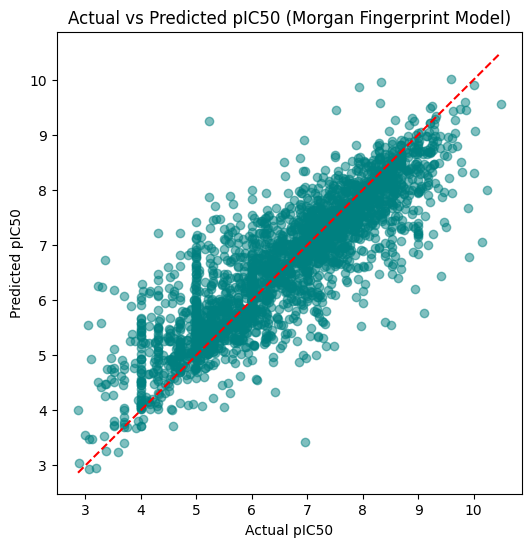

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test_fp, y_pred_fp, alpha=0.5, color='teal')
plt.plot([y_test_fp.min(), y_test_fp.max()], [y_test_fp.min(), y_test_fp.max()], color='red', linestyle='--')
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50 (Morgan Fingerprint Model)")
plt.show()

**Meaning of Block 13:**

Numbers like RMSE and R² tell us how accurate the model is mathematically, but a visual plot makes this result much easier to understand at a glance — especially useful for explaining results in a report, presentation, or thesis defense.

import matplotlib.pyplot as plt — loads Matplotlib, the standard Python library for creating charts and graphs, nicknamed plt by convention.
plt.figure(figsize=(6,6)) — creates a new blank plot, sized 6x6 inches, and square-shaped (important here, so the diagonal reference line — explained below — appears at a true 45-degree angle, not stretched).
plt.scatter(y_test_fp, y_pred_fp, alpha=0.5, color='teal') — this is the core plot. Each dot represents one molecule from our 20% test set: its position on the x-axis is the true, experimentally measured pIC50, and its position on the y-axis is what our model predicted for that same molecule. alpha=0.5 makes each dot semi-transparent, so when many dots overlap in the same area, that region appears darker — helping visualize where most of the data is concentrated.
plt.plot([...], [...], color='red', linestyle='--') — this draws a diagonal reference line representing "perfect prediction" — where predicted value exactly equals actual value. This line goes from the lowest pIC50 value in the test set to the highest, forming a straight 45-degree reference.
How to read the plot: The closer the teal dots cluster around the red dashed line, the more accurate the model is. Dots far above the line mean the model over-predicted potency for that molecule; dots far below mean it under-predicted. A wide, scattered cloud far from the line would indicate poor accuracy — but given our R² = 0.74, you should see a reasonably tight cloud following the diagonal trend, with some natural scatter (expected, since no real-world model is perfect).
plt.xlabel(...), plt.ylabel(...), plt.title(...) — simply label the axes and give the chart a clear title, so it's understandable on its own if shared separately (e.g., in a report).
plt.show() — renders and displays the finished plot.

In [ ]:
import joblib

joblib.dump(model_fp, 'egfr_bioactivity_model.pkl')

from google.colab import files
files.download('egfr_bioactivity_model.pkl')

print("Model saved and downloaded successfully")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Model saved and downloaded successfully


**Meaning of Block 14:**

Right now, our trained model (model_fp) only exists inside this Colab session's temporary memory. If the session disconnects or ends, all that training work (which took a few minutes) would be lost, and it would need to be retrained from scratch. This block saves the trained model permanently as a file, so it can be reloaded instantly in the future — in this same notebook, in a different notebook, or even in one of the other five models planned for later (like Virtual Screening, which needs a trained bioactivity model to score new compounds).

import joblib — loads a library specifically designed for saving and loading trained machine learning models (it's more efficient than regular file-saving methods for this purpose, since models contain complex internal structures like our 100 decision trees).
joblib.dump(model_fp, 'egfr_bioactivity_model.pkl') — this is the key line. "Dump" means "save to disk." It takes our fully trained model object (model_fp, containing everything it learned from the 10,861 training molecules) and writes it into a single file named egfr_bioactivity_model.pkl. The .pkl extension stands for "pickle," Python's standard format for saving objects like this.
from google.colab import files and files.download(...) — same as in Block 5, this triggers your browser to download the saved file directly to your computer's Downloads folder, since Colab's storage is temporary and gets wiped when the session ends.
print("Model saved and downloaded successfully") — a simple confirmation message.